In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)

if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f'figure_{plt._trebl_autosave_counter:04d}'
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import tqdm

# Logistic function
def logistic(t, A, k, t0):
    return A / (1 + np.exp(-k * (t - t0)))

df = activities  # your original dataframe

results = []

for adseq, group in tqdm.tqdm(df.groupby('ADseq')):
    t = group['time'].values
    y = group['activity_norm'].values
    y_err = group['error'].values
    
    # initial guesses
    A_guess = y.max()
    k_guess = 0.1
    t0_guess = t[np.argmin(np.abs(y - A_guess/2))]

    y_err = group['error'].values
    sigma = None if np.all(np.isnan(y_err)) else y_err
    
    try:
        # weighted logistic fit
        popt, pcov = curve_fit(
            logistic, t, y,
            p0=[A_guess, k_guess, t0_guess],
            sigma=sigma,
            absolute_sigma=True if sigma is not None else False,
            maxfev=5000
        )
        
        # fitted parameters
        A_fit, k_fit, t0_fit = popt
        
        # smooth curve only over observed time points
        t_fine = np.linspace(t.min(), t.max(), 1000)
        y_fit = logistic(t_fine, A_fit, k_fit, t0_fit)
        
        # maximum value **within the observed interval**
        max_curve = y_fit.max()
        half_max_curve = max_curve / 2
        
        # time where fitted curve crosses half-max
        t_half_from_curve = t_fine[np.argmin(np.abs(y_fit - half_max_curve))]
        
        # predicted y at measured points
        y_pred = logistic(t, *popt)
        r2 = r2_score(y, y_pred)
        
        # parameter uncertainties
        perr = np.sqrt(np.diag(pcov))
        
        results.append({
            'ADseq': adseq,
            'R2': r2,
            'observed_strength': max_curve,      # max curve value in observed interval
            't_half': t_half_from_curve,         # half-max time
            'speed': k_fit,
            'A_err': perr[0],
            'k_err': perr[1],
            't0_err': perr[2]
        })
        
    except RuntimeError:
        results.append({
            'ADseq': adseq,
            'R2': np.nan,
            'observed_strength': np.nan,
            't_half': np.nan,
            'speed': np.nan,
            'A_err': np.nan,
            'k_err': np.nan,
            't0_err': np.nan
        })

results_df = pd.DataFrame(results)
print(results_df.head())

  9%|▉         | 415/4713 [00:00<00:07, 565.70it/s]/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
 16%|█▌        | 732/4713 [00:01<00:05, 708.25it/s]/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
 22%|██▏       | 1025/4713 [00:01<00:05, 671.09it/s]/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
 37%|███▋      | 1747/4713 [00:02<00:03, 745.10it/s]/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
 43%|████▎     | 2047/4713 [00:02<00:03, 711.22it/s]/tmp/ipykernel_3143365/3577736293.py:30: OptimizeWarning: Cova

                                      ADseq        R2  observed_strength  \
0  AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH  0.901956           3.516401   
1  AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS  0.977080           1.143164   
2  AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS  0.937996           1.921117   
3  AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN  0.962433           1.870561   
4  AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI  0.967676           2.323555   

     t_half     speed     A_err     k_err    t0_err  
0  6.396396  0.258618  0.586544  0.147898  2.587005  
1  8.498498  0.501244  0.228650  0.328210  2.109791  
2  4.834835  0.720401  0.024548  0.128958  0.269447  
3  4.384384  0.455876  0.046699  0.092673  0.345533  
4  4.444444  0.618352  0.090207  0.222306  0.325691  


In [5]:
results_df

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,0.901956,3.516401,6.396396,0.258618,0.586544,0.147898,2.587005
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.977080,1.143164,8.498498,0.501244,0.228650,0.328210,2.109791
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.937996,1.921117,4.834835,0.720401,0.024548,0.128958,0.269447
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,0.962433,1.870561,4.384384,0.455876,0.046699,0.092673,0.345533
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.967676,2.323555,4.444444,0.618352,0.090207,0.222306,0.325691
...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,0.966520,3.046682,4.864865,0.510836,0.237313,0.261700,0.920699
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0.908627,3.476250,4.444444,0.290648,0.037629,0.019202,0.236631
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,0.955471,2.277674,5.015015,0.458889,0.212579,0.244365,1.168426
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,0.961304,1.373053,9.909910,0.204509,0.166912,0.070498,1.994951


In [6]:
ok = results_df[results_df["R2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 4578 / 4713 sequences (97.1%)


In [7]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/logistic_fit_baseline_norm.csv")

In [8]:
not_ok = results_df[results_df["R2"] < 0.7]
not_ok

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
52,ADQWLREKLAVQDYDANHPHQNPKSAWEDFNIRTGFMKGL,0.657783,1.084558,8.138138,0.121530,6.606611e-01,1.673498e-01,1.256031e+01
80,AFSLEEFTAFGGGASTTAYSSPAIPGYDVNASSSSSSTTN,0.479873,2.102959,14.204204,0.043869,7.290619e+08,2.665518e-01,1.315002e+06
140,ALAAQLLTGHAAEPNVAYHSTFGELSSTGDGGLFGMDEHF,0.691061,0.888809,21.561562,0.082131,1.961330e+10,3.200816e-01,5.064183e+06
154,ALQNQRVAAIIQSTGHSINTSALTNRFTPQQSSIQQFYAS,0.485197,0.936374,22.312312,0.090288,1.603238e+10,5.510250e-01,5.187611e+06
209,APNSTAFTALTSPSPYESPDFDVYDVSPHFSTTDFDSGGP,0.445527,2.305495,16.756757,0.052355,7.957884e+09,3.198540e-01,3.591867e+06
...,...,...,...,...,...,...,...,...
4481,VKSPMEVPADLEITETDSLPRRKSSNSPSSSHGHGRHSSV,0.399081,0.900247,11.321321,0.100000,inf,inf,inf
4558,VSPQDLFVRDSFASAPNSAQFTNLTSPSTYNESPEYNEHF,0.545272,1.937920,5.045045,0.655417,8.891740e-02,5.188137e-01,5.822459e-01
4578,VSSEQPLLRFSRSPTATIPPQDFTVFTTDSQQSTWLPSRA,0.464785,0.697950,5.315315,4.883350,3.073801e-01,2.806744e+10,1.790557e+09
4579,VSVFGASSQVELFSLETRFAQLINLSSIDVPFHSSSRFPY,0.620894,0.802483,13.393393,0.077671,4.483132e+00,2.011854e-01,9.774796e+01


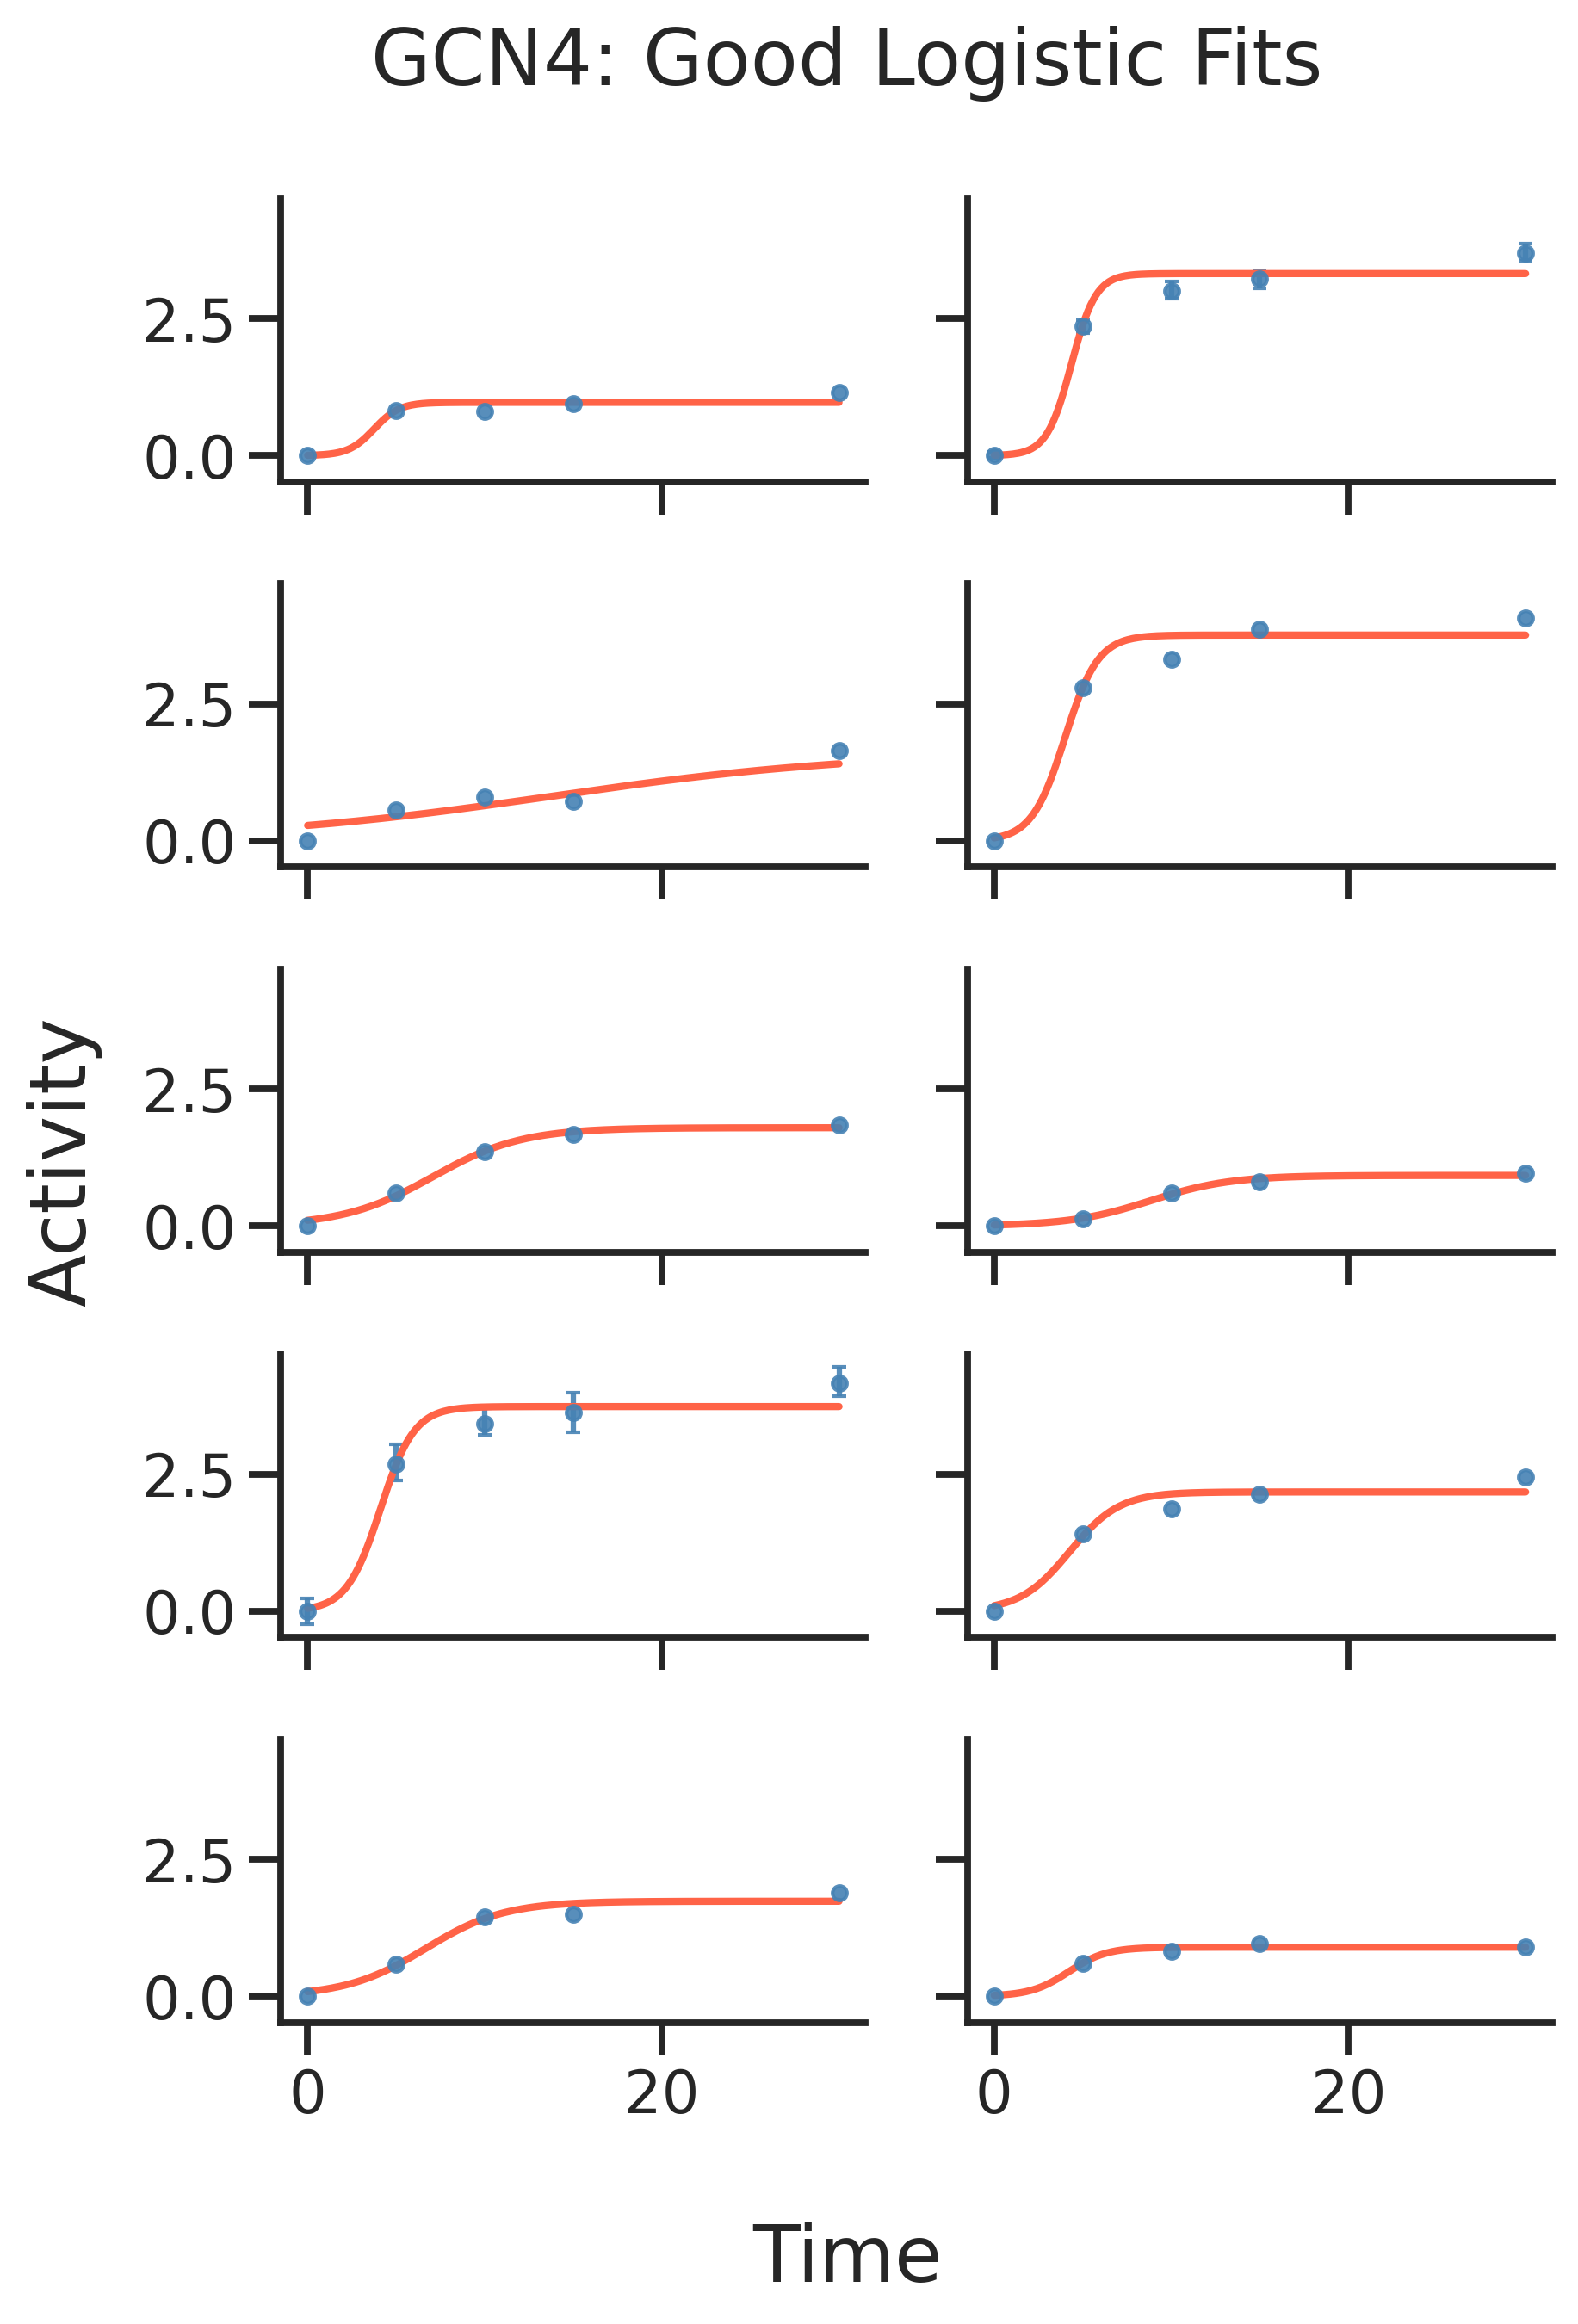

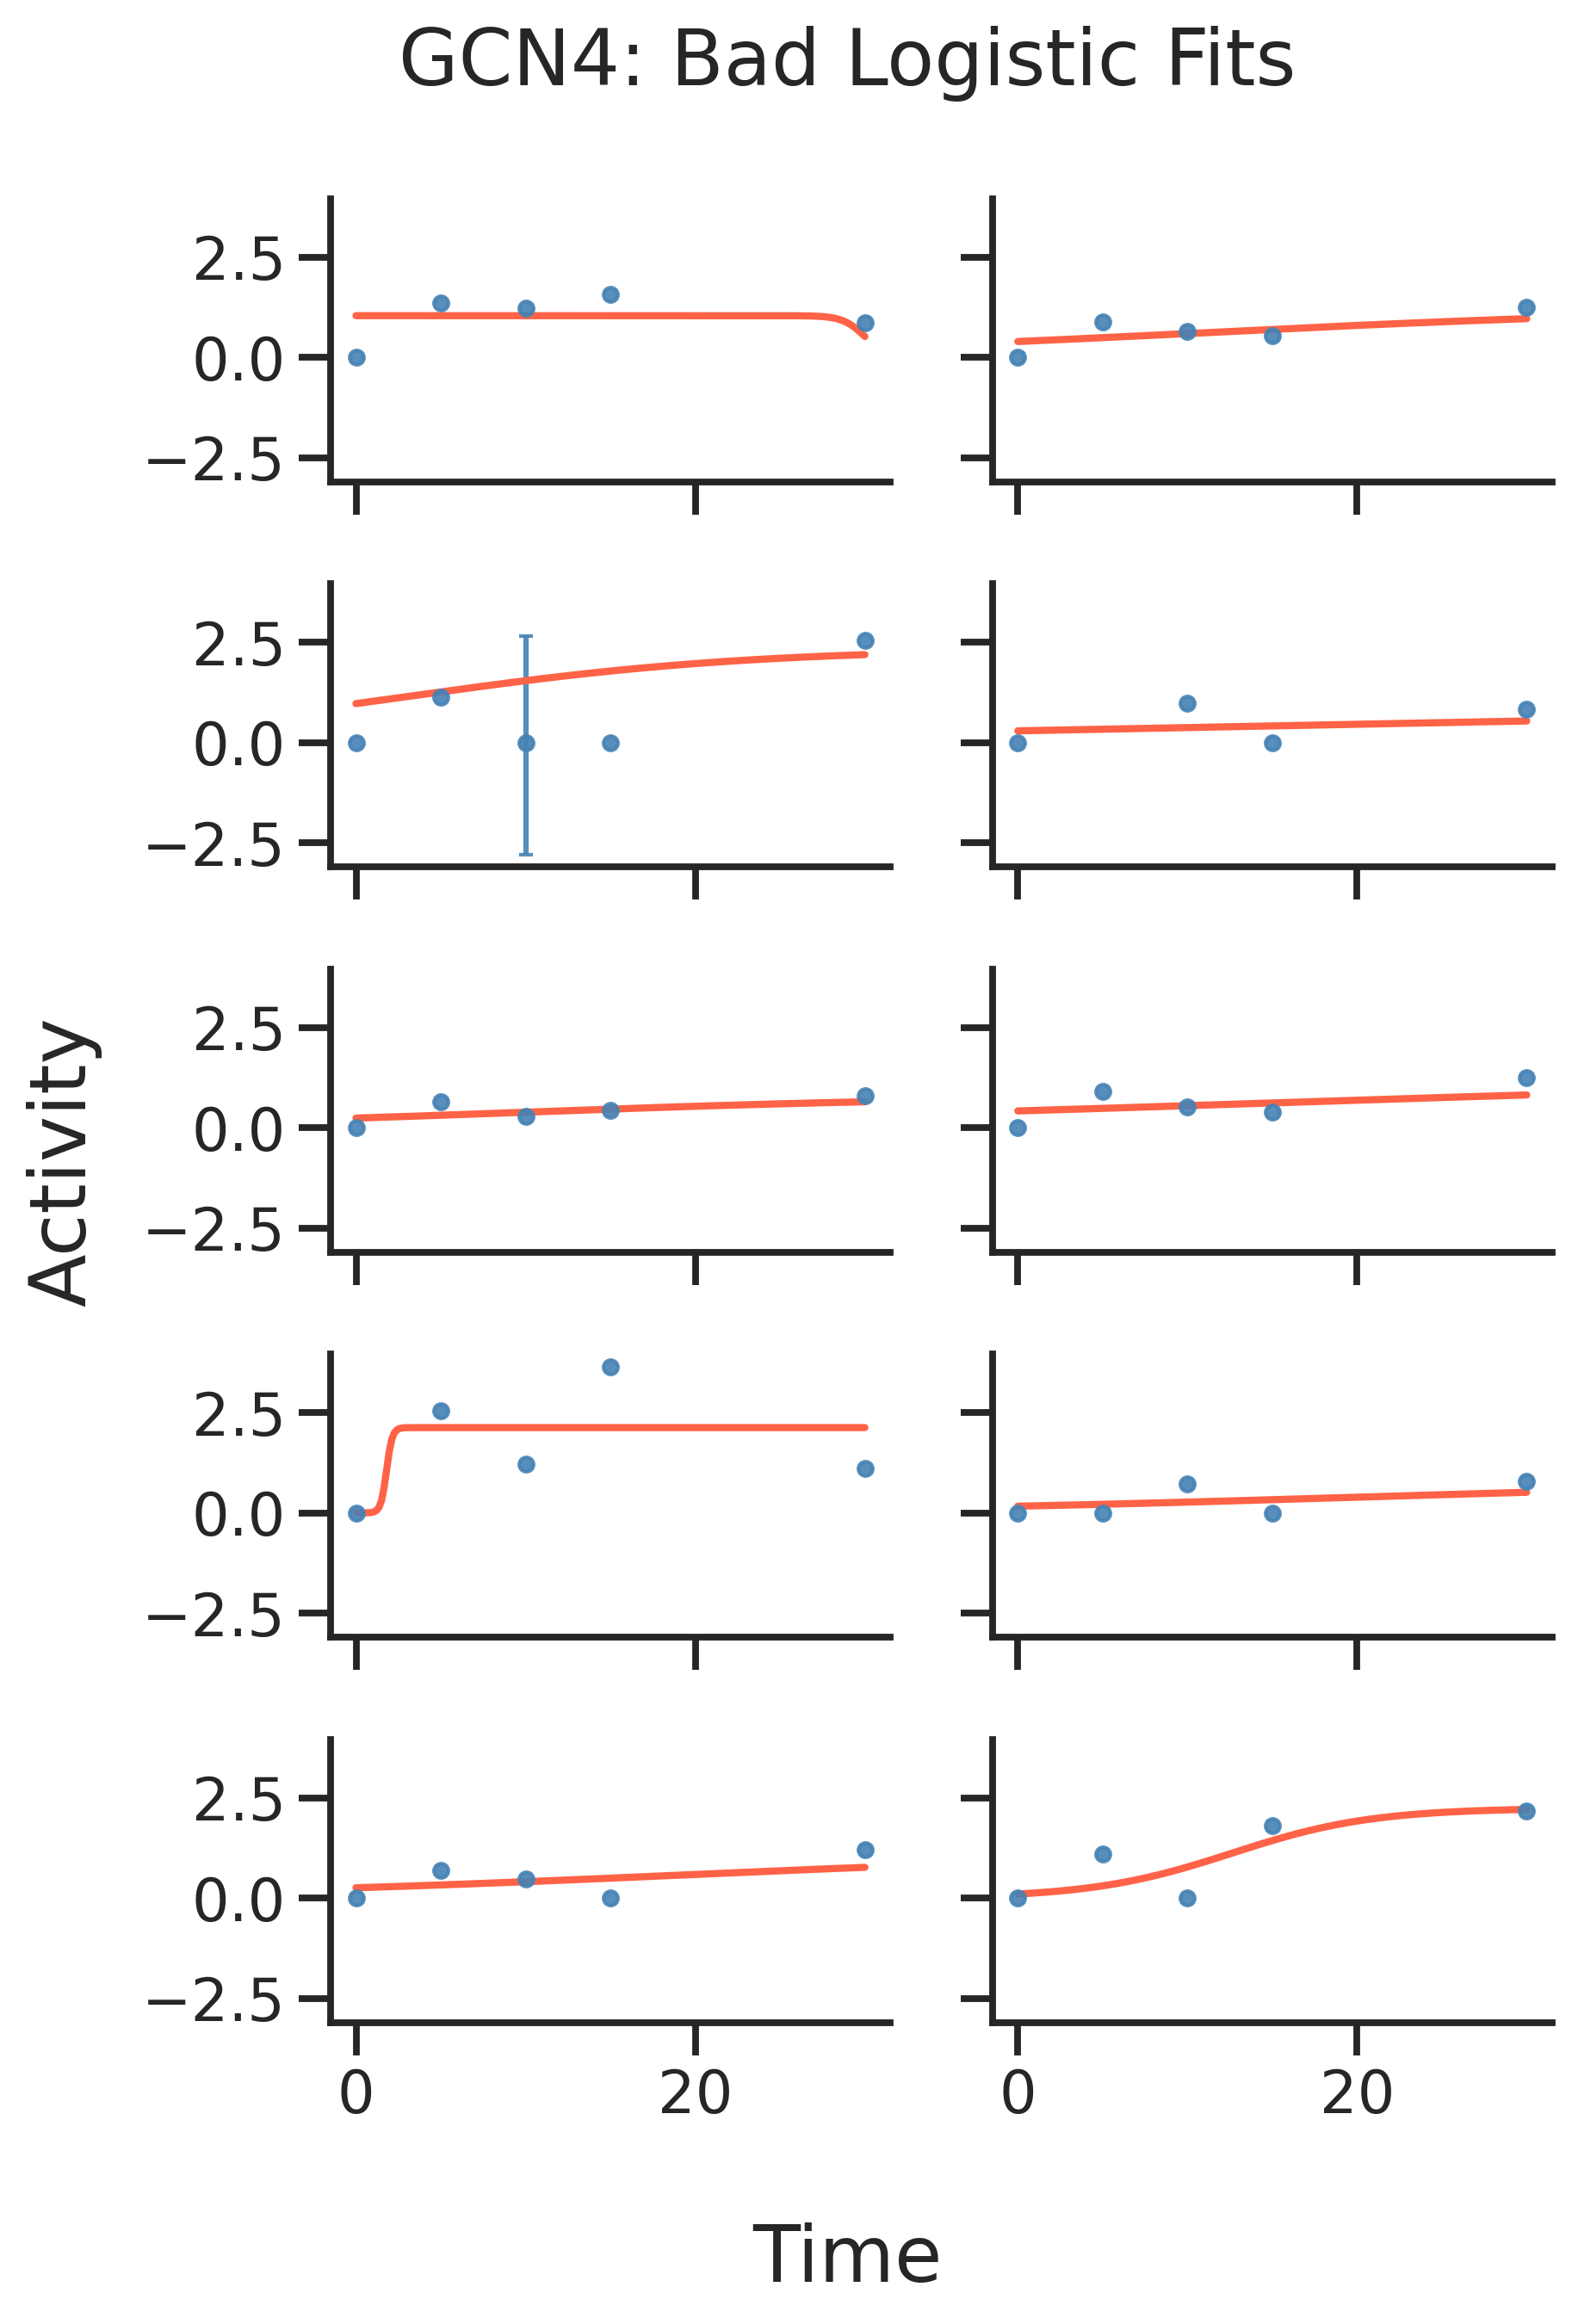

In [9]:
for df, title in zip([ok, not_ok], ["Good", "Bad"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=logistic,
        model_params=['observed_strength', 'speed', 't_half'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'GCN4: {title} Logistic Fits',
    )

Pearson r = -0.516, p = 9.5e-310
Spearman rho = -0.621, p = 0


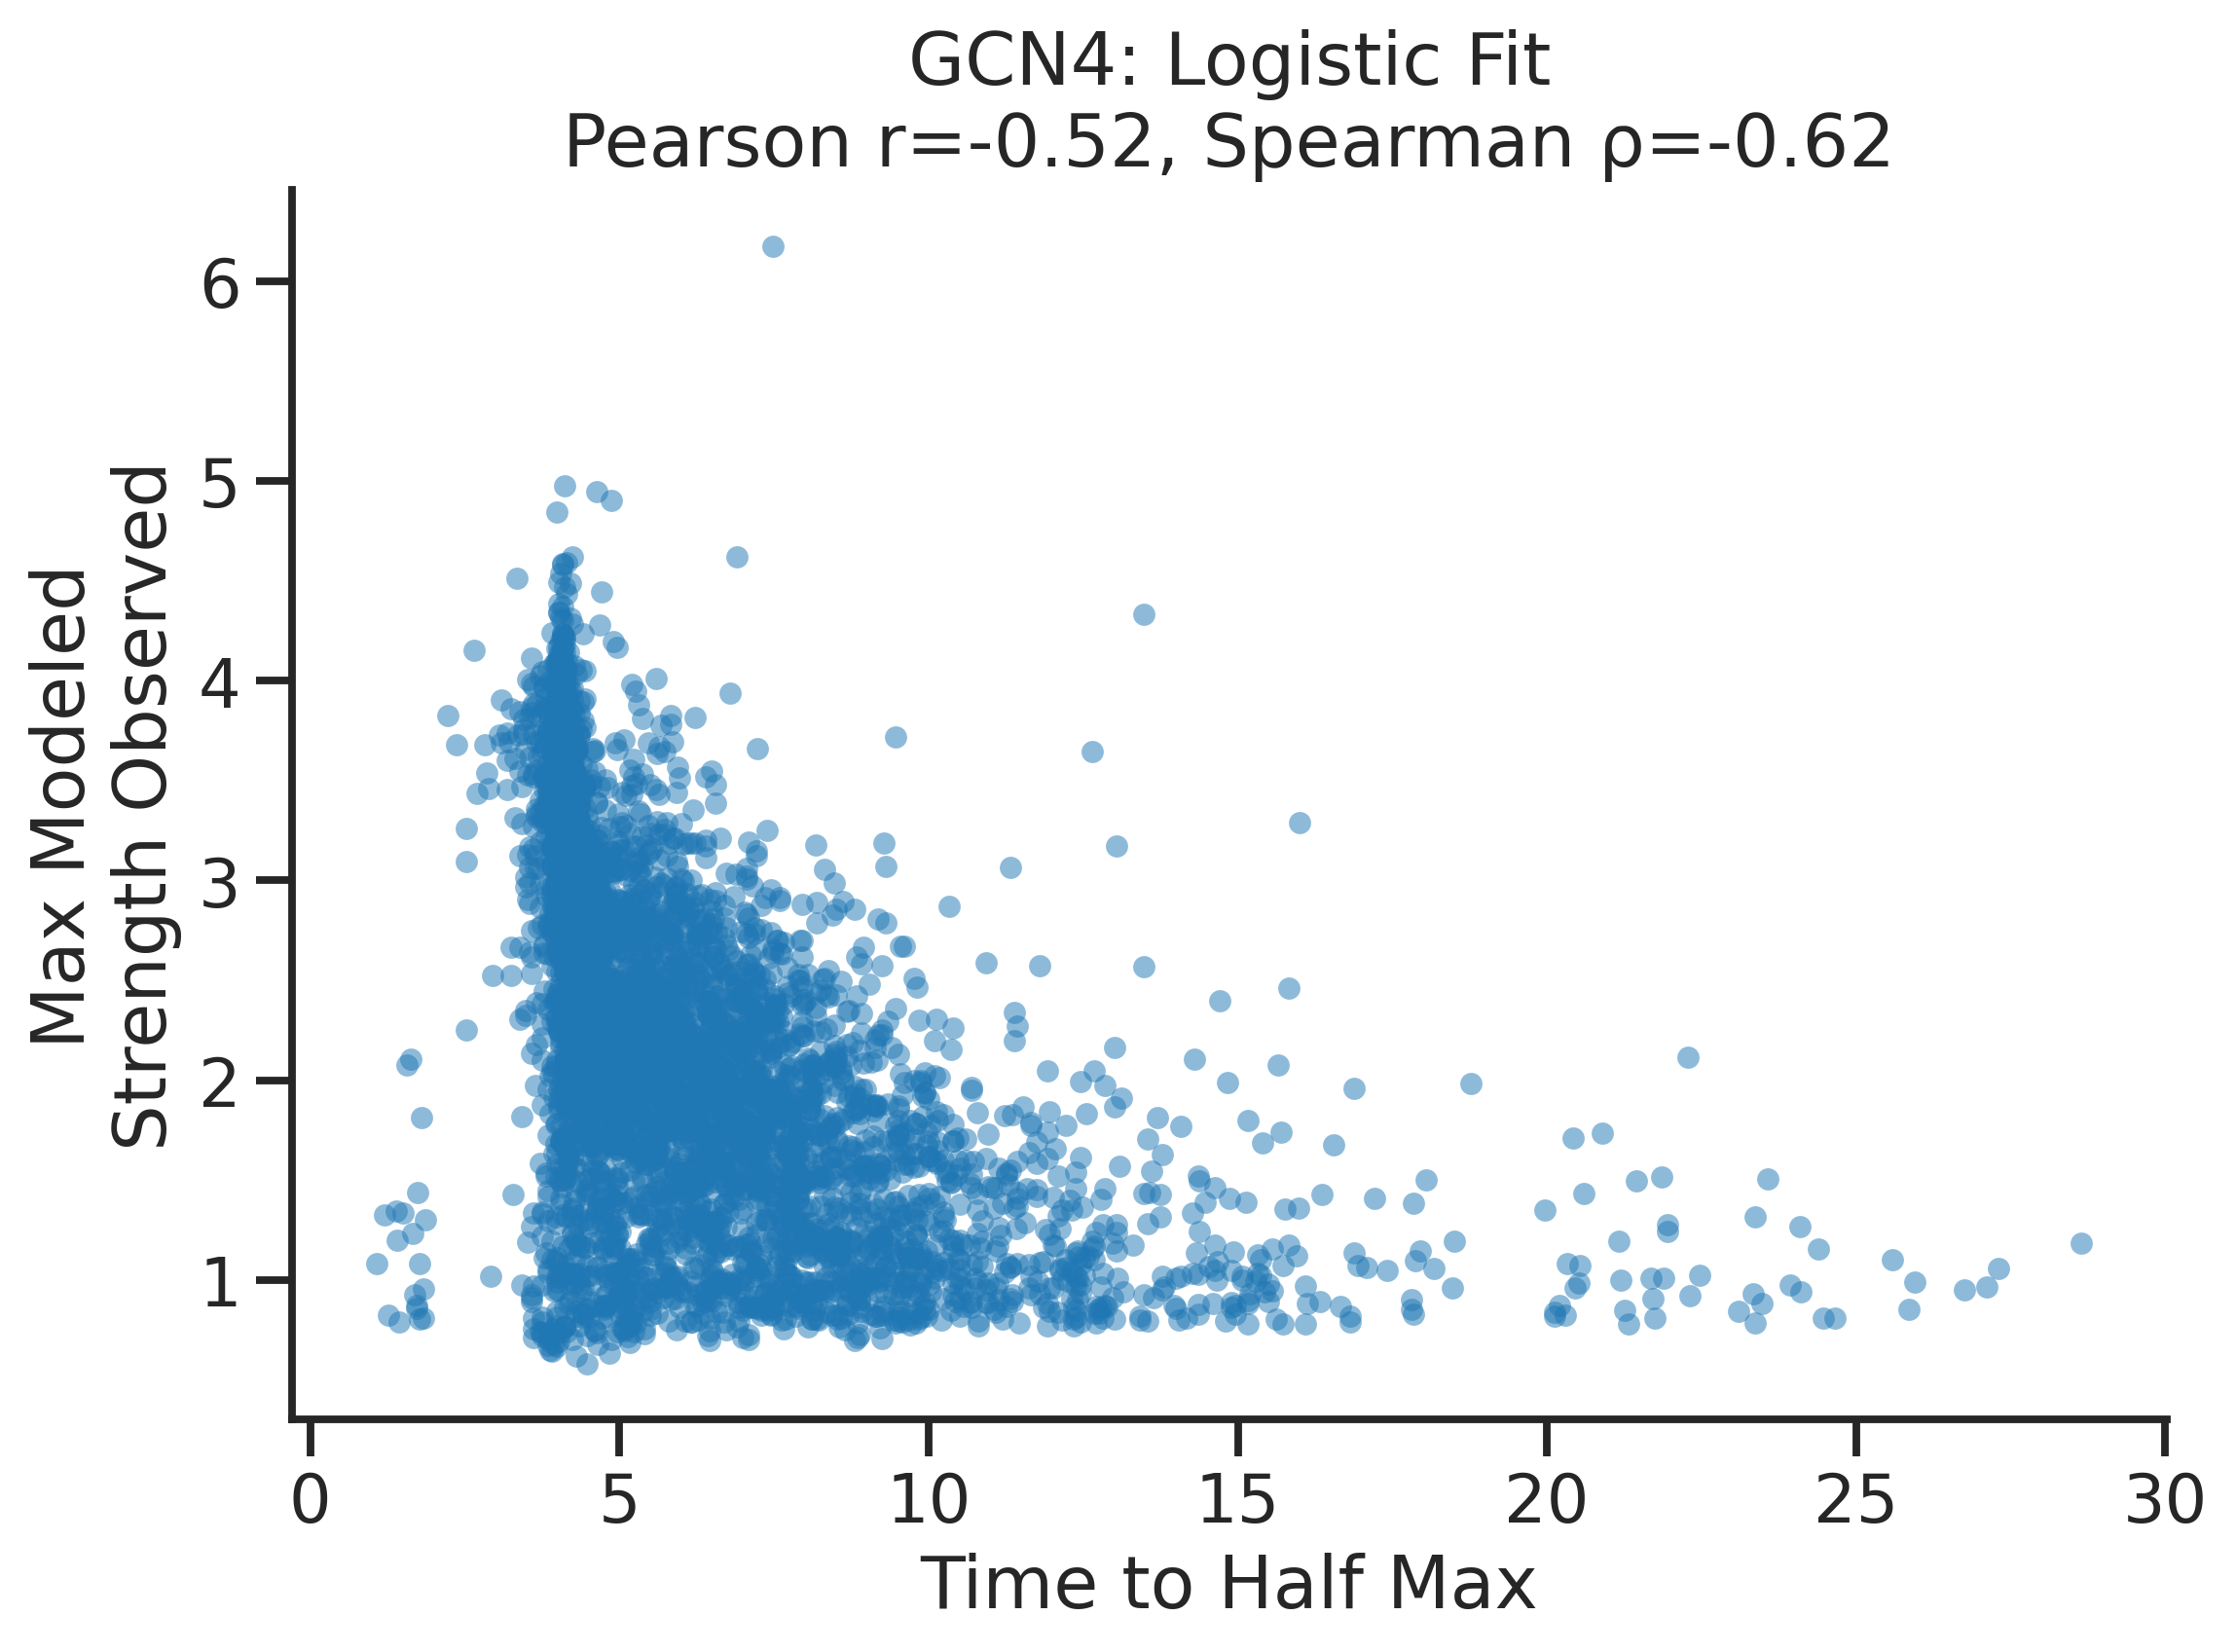

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [11]:
# --- filter valid sequences ---
filtered = results_df[
    (ok['speed'] >= 0) &
    (results_df['observed_strength'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['observed_strength'].median()
A_tol = filtered['observed_strength'].std() * 0.3

similar_A = filtered[(filtered['observed_strength'] >= A_target - A_tol) &
                     (filtered['observed_strength'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('speed')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['speed'].median()
k_tol = filtered['speed'].std() * 0.3

similar_k = filtered[(filtered['speed'] >= k_target - k_tol) &
                     (filtered['speed'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('observed_strength')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,IFNDVLGSAPPSTAFTNLTSPDIGESPYLDNYDQSPGIFA,0.759204,1.867778,13.003003,0.088370,4.170711,1.445759e-01,4.312482e+01
1,NSVAEQMPAQTVSPKDLMMDSSAPPSTSFTDMSTPSFESP,0.955085,2.074997,1.561562,7.945103,0.143708,4.849538e+19,8.733656e+18
2,SLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQ,0.939466,0.696164,6.456456,0.548937,0.085551,3.621334e-01,1.497926e+00
3,KSEEQEDDQFMTIPPLNELDSNVVDAFFSSSTDSTPMFEF,0.973025,6.174425,7.477477,0.291622,0.545942,8.800071e-02,1.273038e+00


Pearson r = -0.516, p = 9.5e-310
Spearman rho = -0.621, p = 0


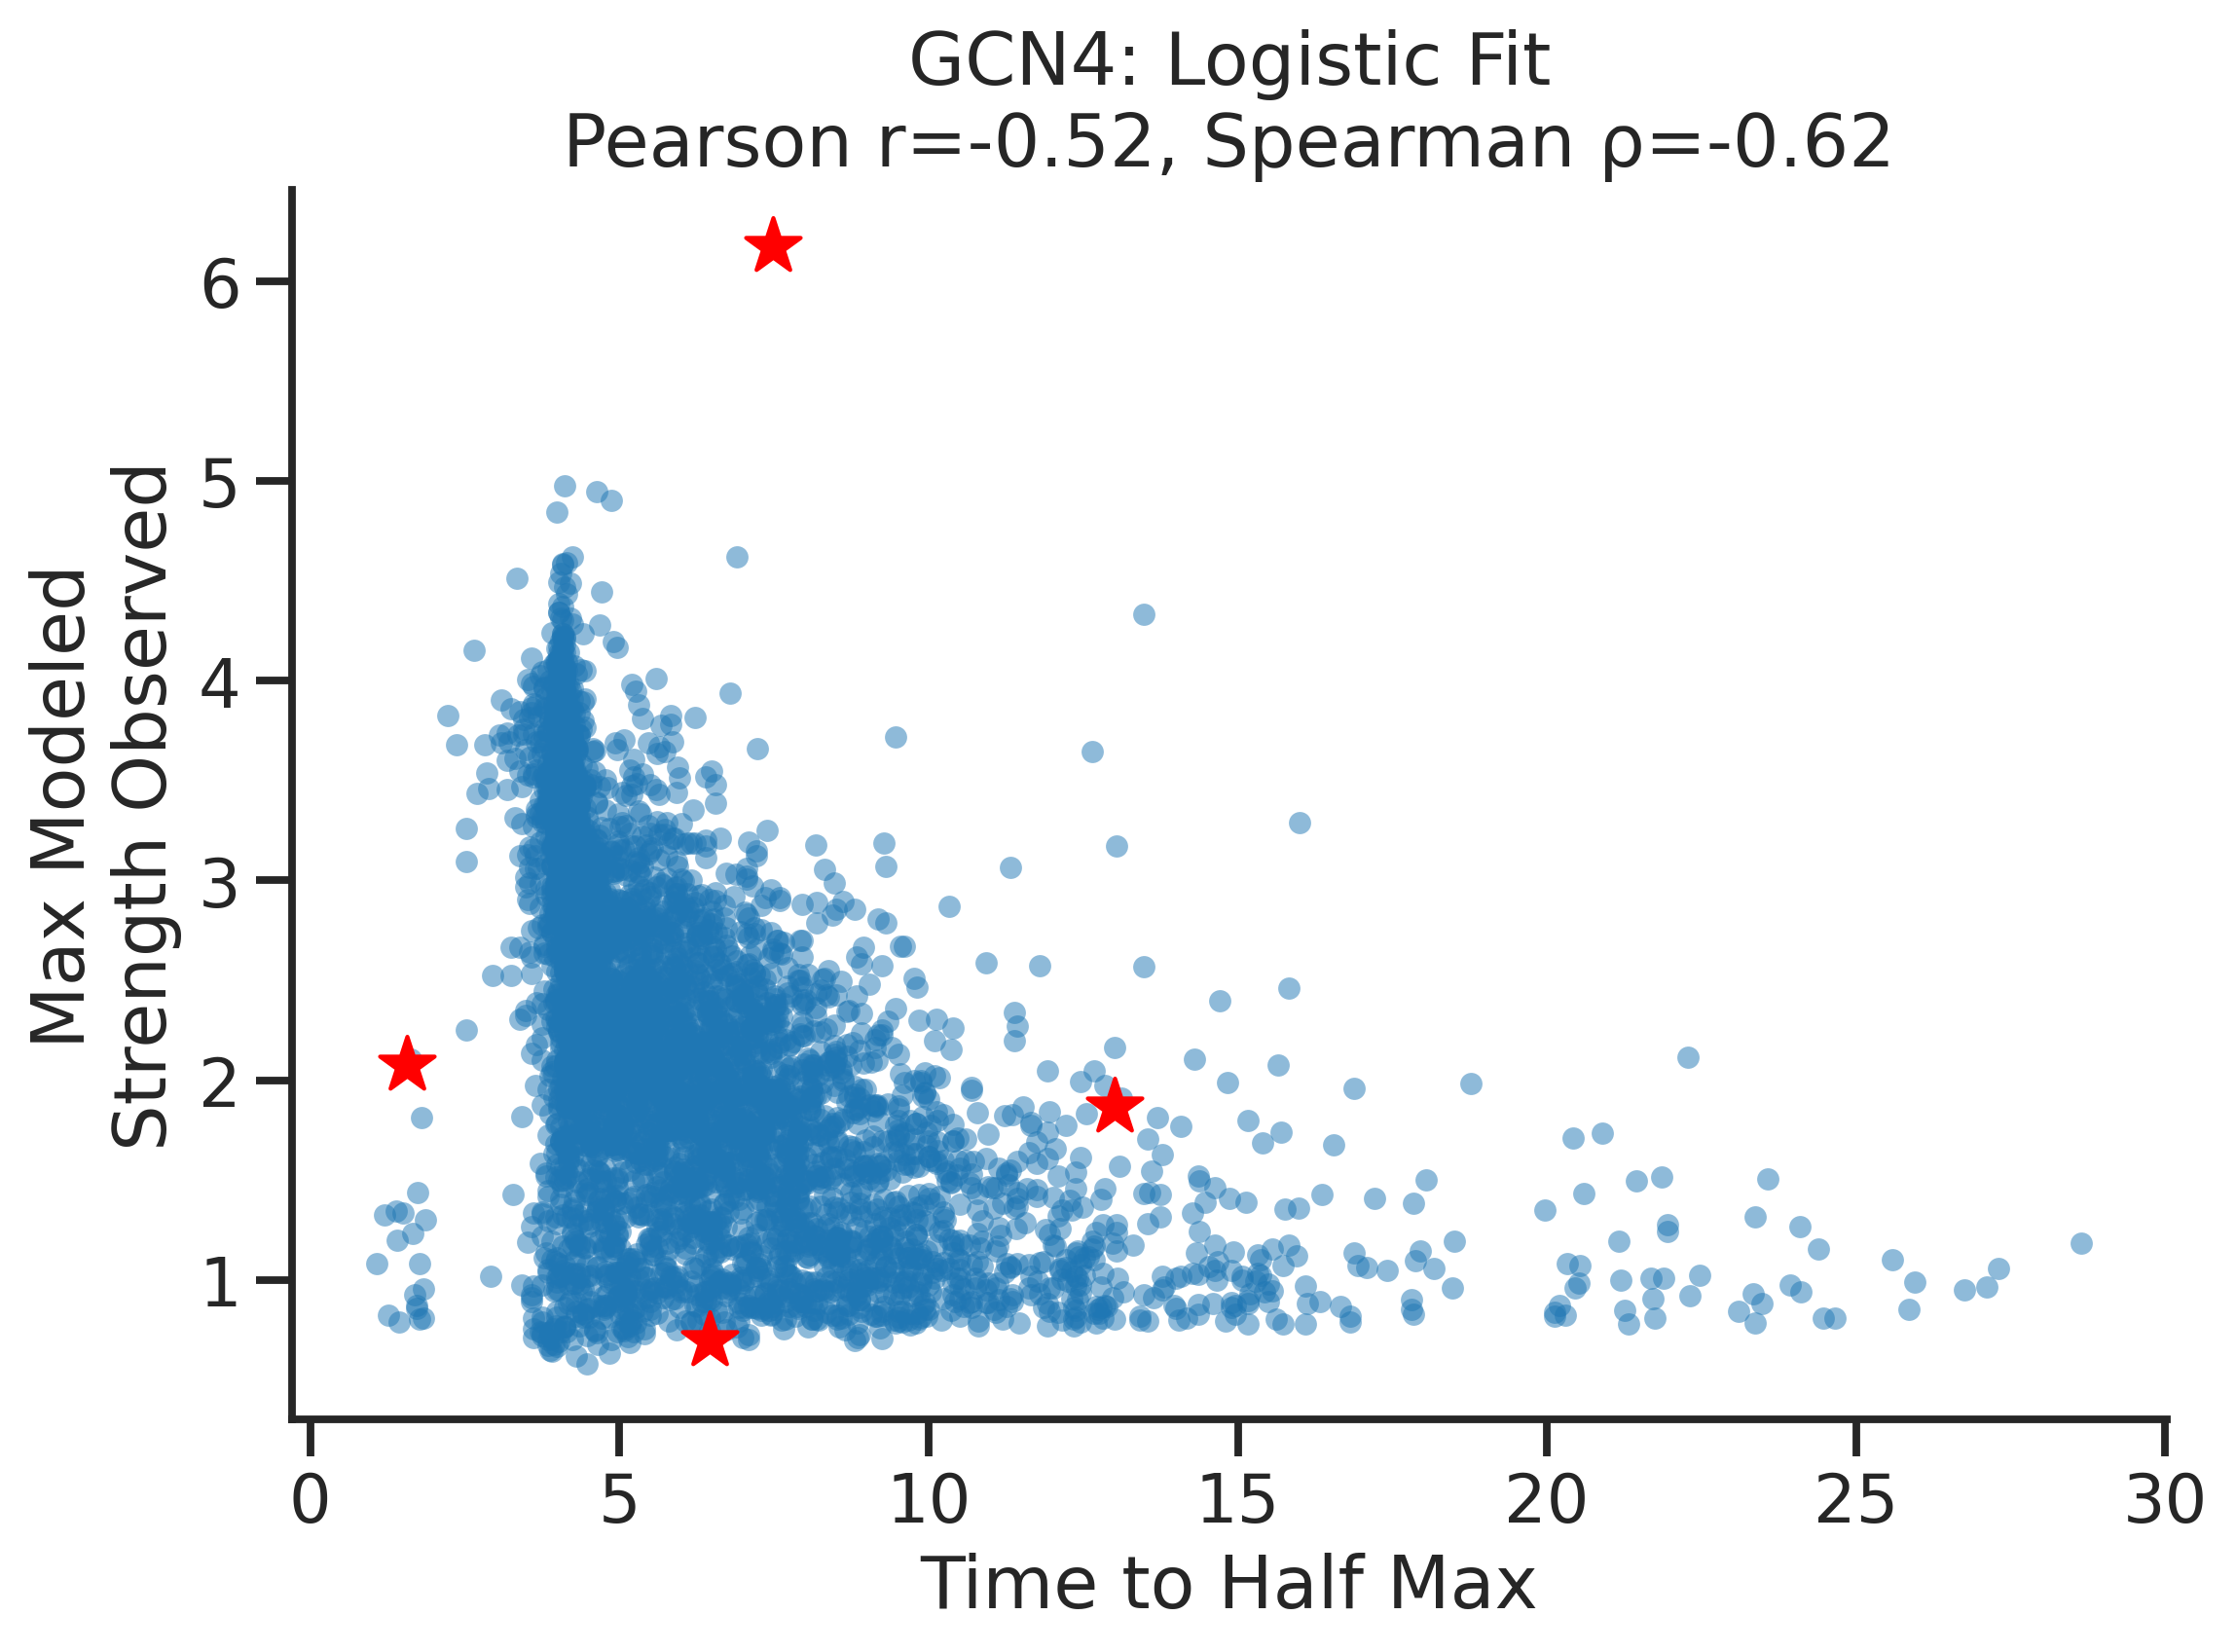

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half'], to_plot['observed_strength'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

ValueError: Axis limits cannot be NaN or Inf

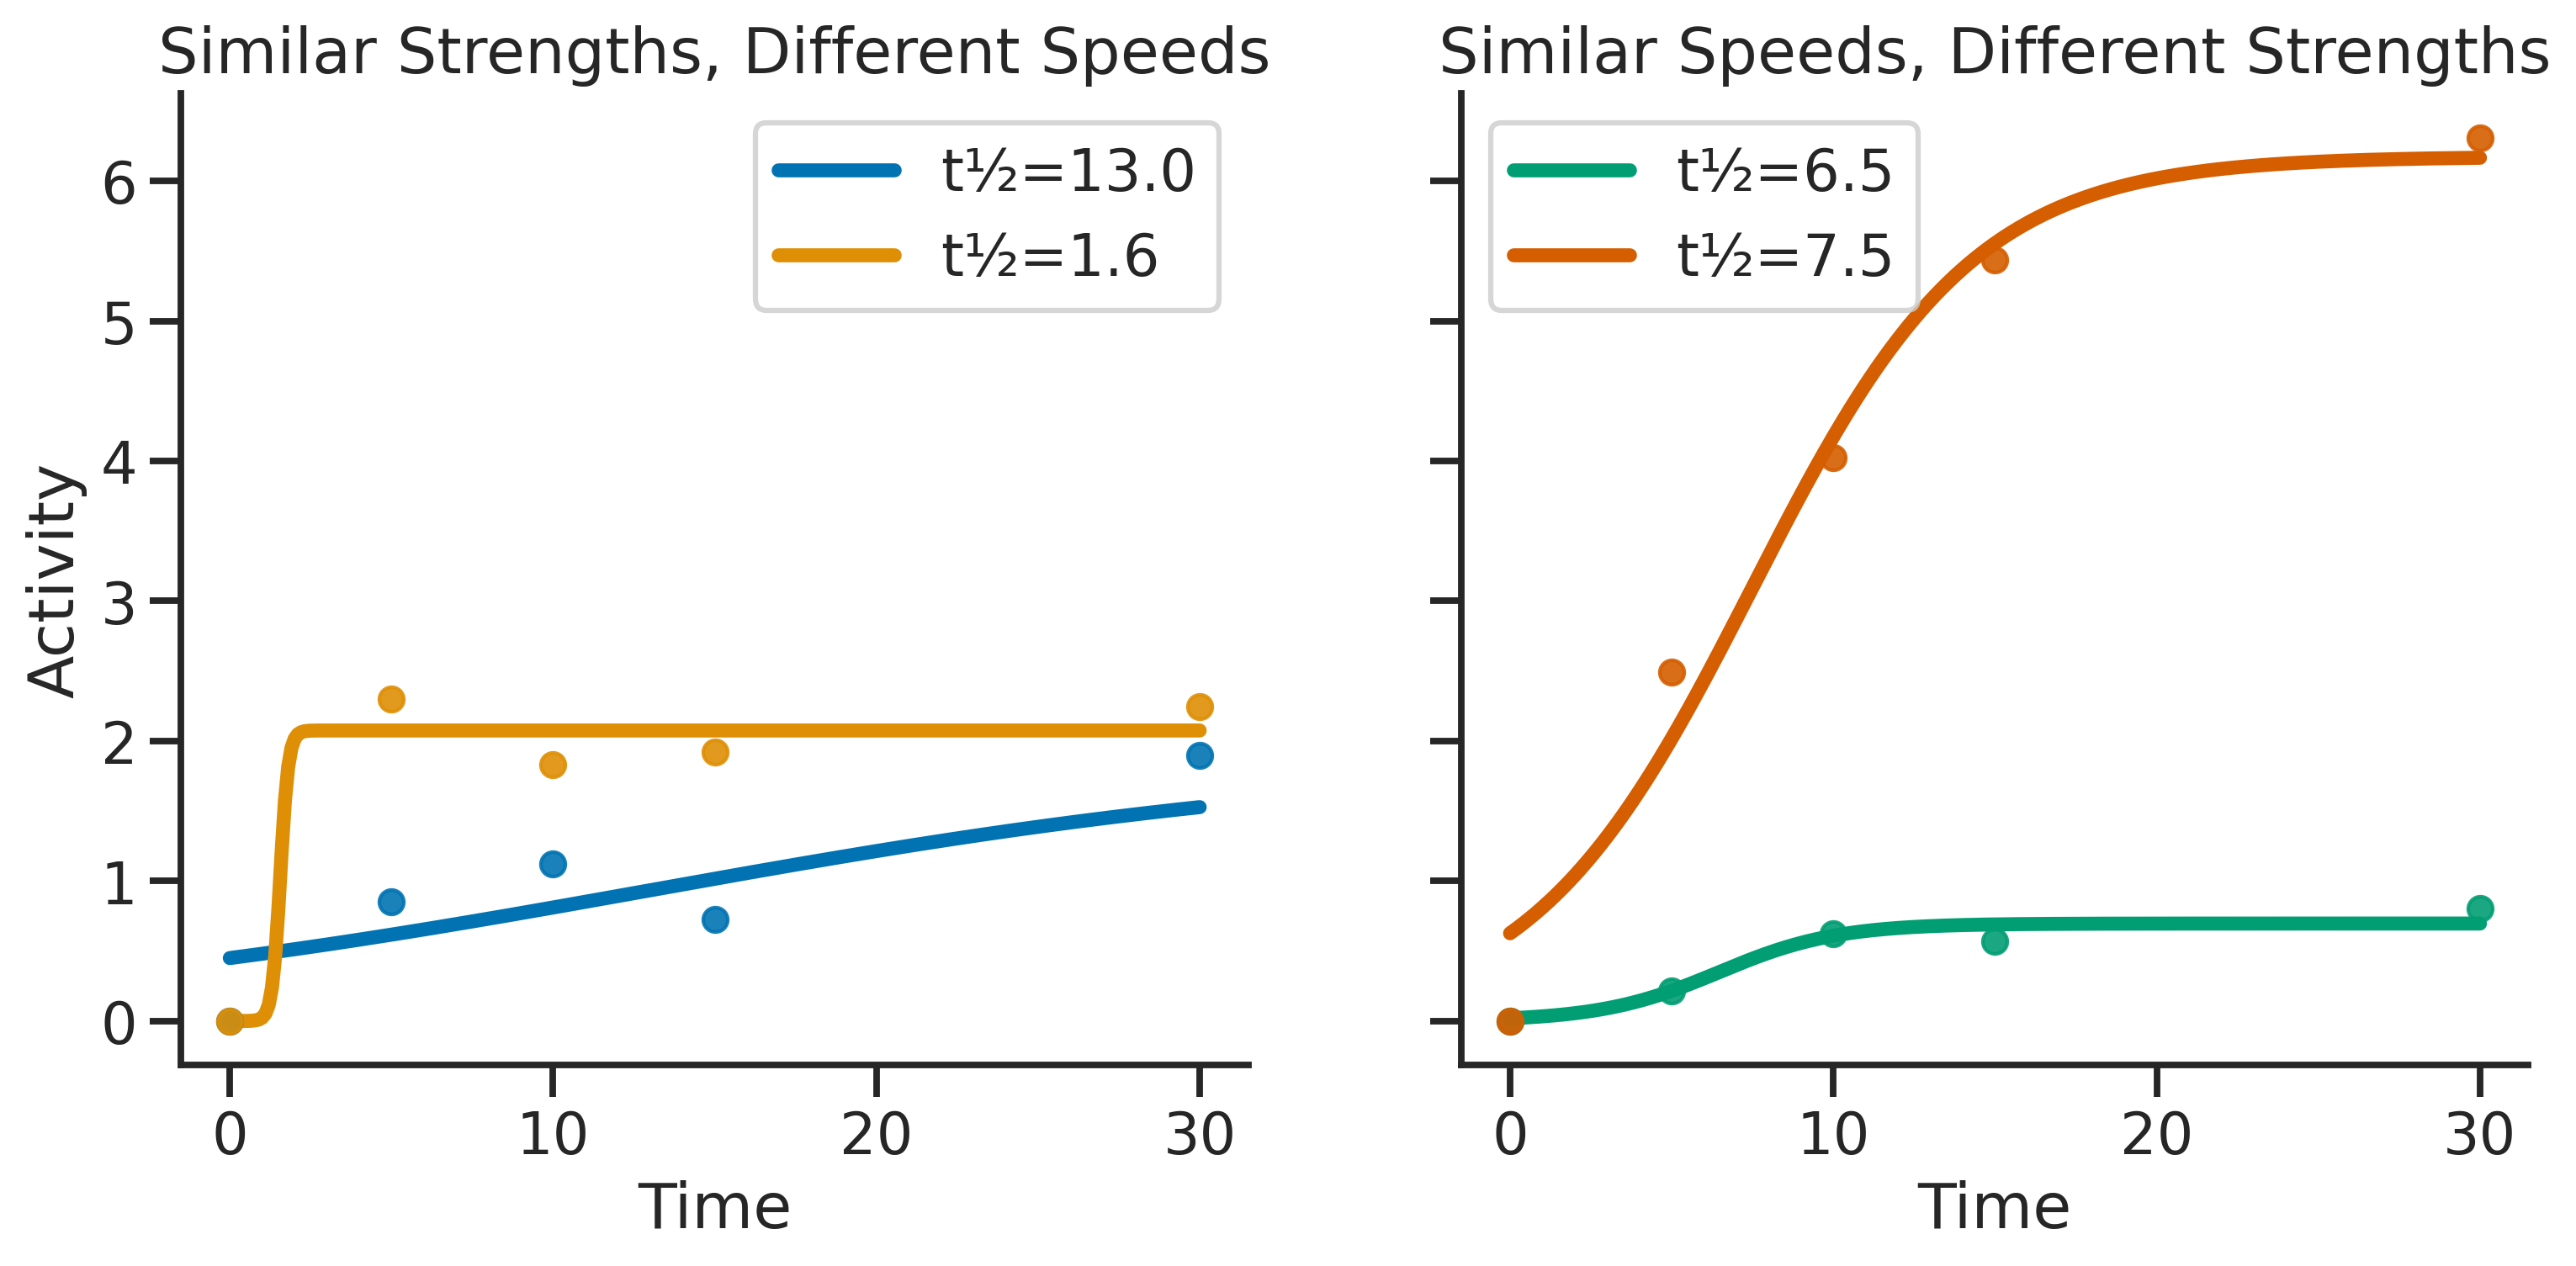

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- logistic function ---
def logistic(t, A, k, t_half):
    return A / (1 + np.exp(-k * (t - t_half)))

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("ChopTFs: Logistic Fit", y=0.912)
plt.tight_layout()
plt.show()